In [3]:
import numpy as np
from PIL import Image
import numpy as np
import torch as th
import blobfile as bf
from PIL import Image
import os, tqdm
import matplotlib.pyplot as plt

def load_image(path):
    with bf.BlobFile(path, "rb") as f:
        pil_image = Image.open(f)
        pil_image.load()
    pil_image = pil_image.convert("RGB")
    return pil_image

def face_segment(segment_part, img_path):
    # print(self.kwargs.keys())
    # print(self.kwargs['in_image_for_cond'].keys())
    # exit()
    face_segment_anno = load_image(img_path)
    
    face_segment_anno = np.array(face_segment_anno)
    bg = (face_segment_anno == 0)
    skin = (face_segment_anno == 1)
    l_brow = (face_segment_anno == 2)
    r_brow = (face_segment_anno == 3)
    l_eye = (face_segment_anno == 4)
    r_eye = (face_segment_anno == 5)
    eye_g = (face_segment_anno == 6)
    l_ear = (face_segment_anno == 7)
    r_ear = (face_segment_anno == 8)
    ear_r = (face_segment_anno == 9)
    nose = (face_segment_anno == 10)
    mouth = (face_segment_anno == 11)
    u_lip = (face_segment_anno == 12)
    l_lip = (face_segment_anno == 13)
    neck = (face_segment_anno == 14)
    neck_l = (face_segment_anno == 15)
    cloth = (face_segment_anno == 16)
    hair = (face_segment_anno == 17)
    hat = (face_segment_anno == 18)
    l_pupil = (face_segment_anno == 19)
    r_pupil = (face_segment_anno == 20)
    face = np.logical_or.reduce((skin, l_brow, r_brow, l_eye, l_pupil, r_eye, r_pupil, eye_g, l_ear, r_ear, ear_r, nose, mouth, u_lip, l_lip))

    if segment_part == 'faceseg_face':
        seg_m = face
    elif segment_part == 'faceseg_head':
        seg_m = (face | neck | hair)
    elif segment_part == 'faceseg_nohead':
        seg_m = ~(face | neck | hair)
    elif segment_part == 'faceseg_hair':
        seg_m = hair
    elif segment_part == 'faceseg_eyes':
        seg_m = (l_eye | r_eye | l_pupil | r_pupil)
    elif segment_part == 'faceseg_pupils':
        seg_m = (l_pupil | r_pupil)
    elif segment_part == 'faceseg_ears':
        seg_m = (l_ear | r_ear | ear_r)
    elif segment_part == 'faceseg_nose':
        seg_m = nose
    elif segment_part == 'faceseg_mouth':
        seg_m = (mouth | u_lip | l_lip)
    elif segment_part == 'faceseg_u_lip':
        seg_m = u_lip
    elif segment_part == 'faceseg_l_lip':
        seg_m = l_lip
    elif segment_part == 'faceseg_inmouth':
        seg_m = mouth
    elif segment_part == 'faceseg_neck':
        seg_m = neck
    elif segment_part == 'faceseg_glasses':
        seg_m = eye_g
    elif segment_part == 'faceseg_cloth':
        seg_m = cloth
    elif segment_part == 'faceseg_hat':
        seg_m = hat
    elif segment_part == 'faceseg_face&hair':
        seg_m = ~bg
    elif segment_part == 'faceseg_bg_noface&nohair':
        seg_m = (bg | hat | neck | neck_l | cloth) 
    elif segment_part == 'faceseg_bg&ears_noface&nohair':
        seg_m = (bg | hat | neck | neck_l | cloth) | (l_ear | r_ear | ear_r)
    elif segment_part == 'faceseg_bg':
        seg_m = bg
    elif segment_part == 'faceseg_bg&noface':
        seg_m = (bg | hair | hat | neck | neck_l | cloth)
    elif segment_part == 'faceseg_faceskin':
        seg_m = skin
    elif segment_part == 'faceseg_faceskin&nose':
        seg_m = (skin | nose)
    elif segment_part == 'faceseg_faceskin&nose&mouth&eyebrows':
        seg_m = (skin | nose | mouth | u_lip | l_lip | l_brow | r_brow | l_eye | r_eye)    
    elif segment_part == 'faceseg_faceskin&nose&mouth&eyebrows&eyes&glasses':
        seg_m = (skin | nose | mouth | u_lip | l_lip | l_brow | r_brow | l_eye | r_eye | l_pupil | r_pupil | eye_g)
    elif segment_part == 'faceseg_eyes&glasses':
        seg_m = (l_eye | r_eye | eye_g | l_pupil | r_pupil)
    elif segment_part == 'faceseg_face_noglasses':
        seg_m = (~eye_g & face)
    elif segment_part == 'faceseg_face_noglasses_noeyes':
        seg_m = (~(l_eye | r_eye) & ~eye_g & face)
    elif segment_part in ['sobel_bg_mask', 'laplacian_bg_mask', 'sobel_bin_bg_mask']:
        seg_m = ~(face | neck | hair)
    elif segment_part in ['canny_edge_bg_mask']:
        seg_m = ~(face | neck | hair) | (l_ear | r_ear)
    else: raise NotImplementedError(f"Segment part: {segment_part} is not found!")
    
    out = seg_m
    return out

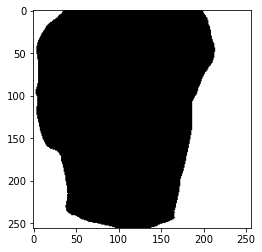

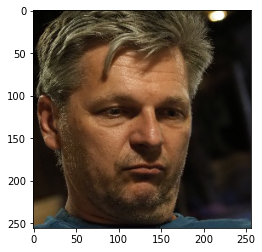

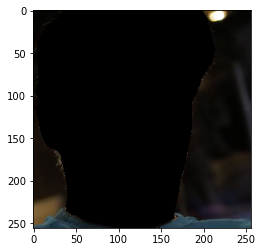

In [17]:
img_name = '24984'
mask = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/face_segment/train/anno/anno_{img_name}.png'
img = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/train/{img_name}.jpg'

segment_part = 'faceseg_nohead'
mask = face_segment(segment_part, mask)
plt.imshow(mask*1.0)
plt.show()

img = load_image(img)
plt.imshow(img)
plt.show()

img_nohead = np.array(img) * mask
plt.imshow(img_nohead)
plt.show()
Image.fromarray(img_nohead).save(f'./{img_name}_{segment_part}.jpg')

